# Gráficos de línea y de dispersión

Teniendo las bases para la generación de gráficas vistas en el módulo anterior, en este último módulo del curso veremos cómo generar diferentes tipos de gráficas especializadas de uso común en nuestros proyectos de Ciencia de Datos y Machine Learning.

Pero además de ver cómo generar de forma básica estas gráficas, veremos elementos adicionales que permitirán personalizarlas y lograr mejores visualizaciones.

Y comenzaremos con dos de los tipos de gráficos más comunes: los gráficos de línea y de dispersión.

## 1. Gráficos de línea

En este tipo de gráfica, que ya hemos generado anteriormente por medio de la función `plot`, se traza entre cada par de puntos consecutivos una línea recta (de allí el nombre: gráfico de línea).

¿Cuándo usamos este tipo de gráfico?

- Cuando queremos ver cambios en el tiempo. Por ejemplo, variaciones de temperatura en los últimos meses
- O cuando tenemos datos donde la variable independiente es continua. Por ejemplo ¿cómo cambia la presión atmosférica con la altura?

Antes de generar el gráfico comencemos eligiendo el [estilo de color](https://matplotlib.org/stable/gallery/style_sheets/style_sheets_reference.html), pues Matplotlib tiene estilos pre-definidos con paletas de color mucho mejores que las usadas por defecto:

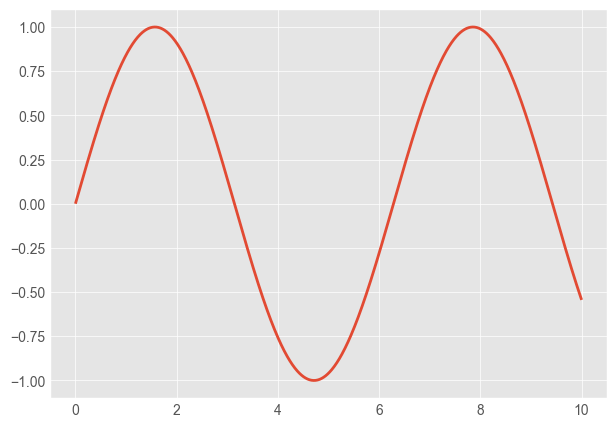

In [5]:
# Importar Pyplot y NumPy
import matplotlib.pyplot as plt
import numpy as np

# Definir estilo de color (ejemplos interesantes: seaborn-whitegrid, fivethirtyeight, bmh, ggplot)
#plt.style.use('default')
#plt.style.use('seaborn-v0_8-whitegrid')
#plt.style.use('fivethirtyeight')
#plt.style.use('bmh')
plt.style.use('ggplot')

# Y generemos una gráfica simple, de una función senoidal
x = np.linspace(0,10,1000)
y = np.sin(x)

fig, ax = plt.subplots()
ax.plot(x,y);

Con el estilo de color seleccionado ya existe un ciclo de colores pre-definido. Así que al añadir una nueva curva a la misma gráfica, automáticamente será seleccionado el color correspondiente:

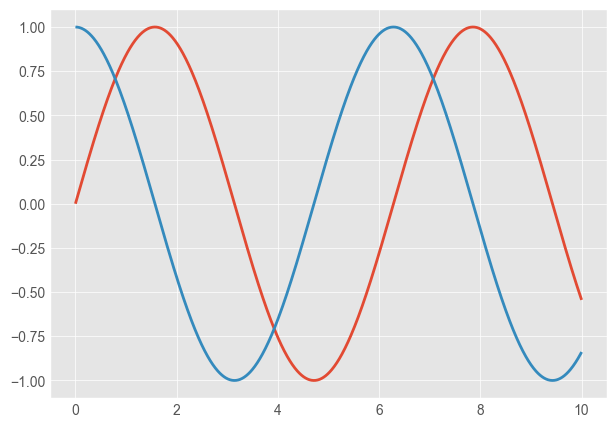

In [6]:
y1 = np.sin(x)
y2 = np.cos(x)

fig, ax = plt.subplots()
ax.plot(x,y1)
ax.plot(x,y2);

Y ahora personalicemos varios elementos:

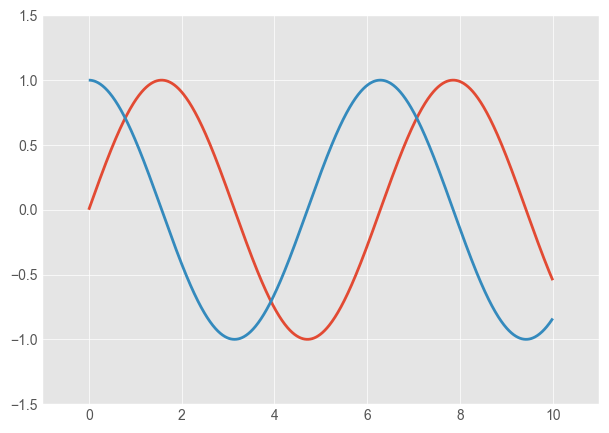

In [7]:
# Primero ajustemos los límites de x y y (usando xlim y ylim):

# Gráfica básica
fig, ax = plt.subplots()

# Límites ejes
ax.set_xlim(-1, 11)
ax.set_ylim(-1.5, 1.5);

# Graficar
ax.plot(x,y1)
ax.plot(x,y2);

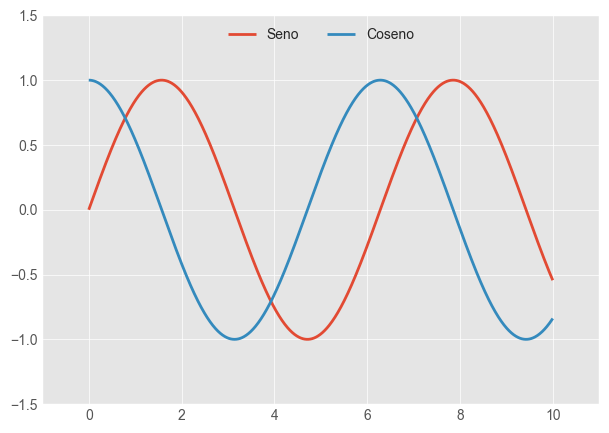

In [9]:
# Ahora añadamos leyendas

# Gráfica básica
fig, ax = plt.subplots()

# Límites ejes
ax.set_xlim(-1, 11)
ax.set_ylim(-1.5, 1.5);

# Graficar (añadir leyenda)
ax.plot(x,y1,label='Seno')
ax.plot(x,y2,label='Coseno')
ax.legend(loc='upper center', ncols=2);

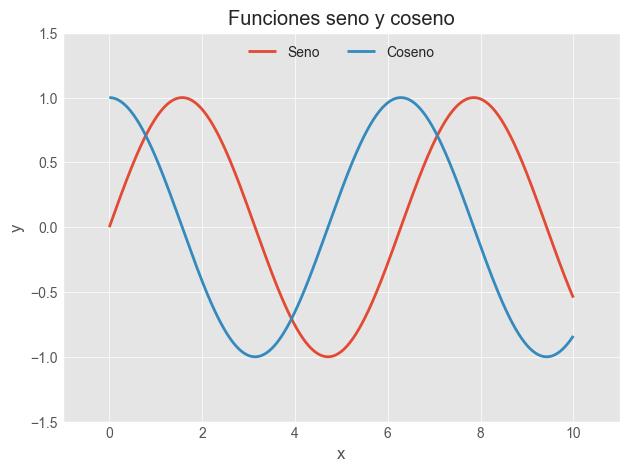

In [11]:
# Agreguemos un título y etiquetas a los ejes

# Gráfica básica
fig, ax = plt.subplots()

# Límites ejes
ax.set_xlim(-1, 11)
ax.set_ylim(-1.5, 1.5);

# Título y etiquetas
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Funciones seno y coseno')

# Graficar (añadir leyenda)
ax.plot(x,y1,label='Seno')
ax.plot(x,y2,label='Coseno')
ax.legend(loc='upper center', ncol=2);

¡Muy bien! Con muy pocas líneas de código hemos logrado generar una gráfica bastante llamativa.

## 2. Gráficas de dispersión

Las gráficas de dispersión son muy similares a las gráficas de línea.

Mientras que en el primer caso (cuando usamos la función `plot`) cada par de datos consecutivos se une a través de una línea, en el segundo caso (gráfica de dispersión usando la función `scatter`) cada dato se dibuja como un punto individual. Y este punto puede tener diferentes formas y colores.

¿Cuándo usar una gráfica de dispersión?

- Cuando queremos identificar si dos variables están relacionadas. Por ejemplo: ¿hay relación entre el número de horas de estudio y el puntaje obtenido por los estudiantes en un examen?
- Para comparar dos grupos de datos. Por ejemplo comparar la altura de hombres y mujeres en una muestra de una población
- Para identificar valores extremos (*outliers*)

Veamos cómo generar una gráfica de dispersión y cómo personalizarla.

Para esta parte usaremos el set de datos *california_cities.csv* que contiene información geográfica y de población de diferentes ciudades de California.

Para leer el set de datos usaremos la librería Pandas:

In [19]:
# Si no está instalada esta librería lo podemos hacer usando pip:
# !pip install pandas
import pandas as pd

ciudades = pd.read_csv('california_cities.csv')
ciudades.head()

,Unnamed: 0,city,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,area_land_sq_mi,area_water_sq_mi,area_total_km2,area_land_km2,area_water_km2,area_water_percent
0,0,Adelanto,34.576111,-117.432778,875.0,2871.0,31765,56.027,56.009,0.018,145.107,145.062,0.046,0.03
1,1,AgouraHills,34.153333,-118.761667,281.0,922.0,20330,7.822,7.793,0.029,20.260,20.184,0.076,0.37
2,2,Alameda,37.756111,-122.274444,NaN,33.0,75467,22.960,10.611,12.349,59.465,27.482,31.983,53.79
3,3,Albany,37.886944,-122.297778,NaN,43.0,18969,5.465,1.788,3.677,14.155,4.632,9.524,67.28
4,4,Alhambra,34.081944,-118.135000,150.0,492.0,83089,7.632,7.631,0.001,19.766,19.763,0.003,0.01


In [15]:
# En este caso sólo nos interesan 4 variables por cada ciudad:
# - latd: latitud
# - longd: longitud
# - population_total: población total
# - area_total_km2: área total en Km^2
latitud = ciudades['latd']
longitud = ciudades['longd']
poblacion = ciudades['population_total']
area = ciudades['area_total_km2']

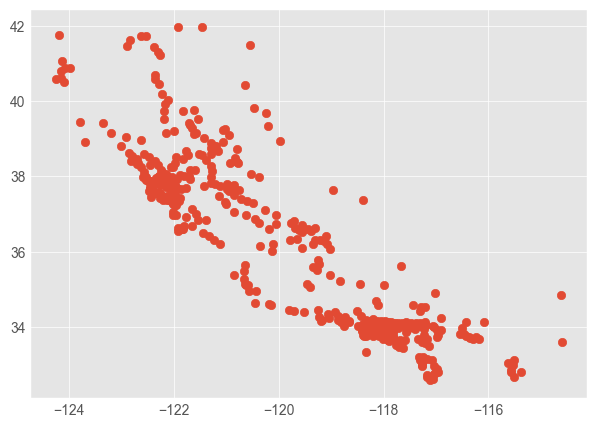

In [16]:
# Generemos una primera gráfica de dispersión con las variables
# longitud (eje horizontal) y latitud (eje vertical)
fig, ax = plt.subplots()
ax.scatter(longitud, latitud);

En esta primera gráfica podemos ver que efectivamente los datos tienen una distribución geográfica. Observemos también que precisamente por tratarse de datos discretos, lo que más resulta útil en este caso es una gráfica de dispersión.

Comencemos a personalizar la gráfica. Añadamos inicialmente etiquetas a los ejes:

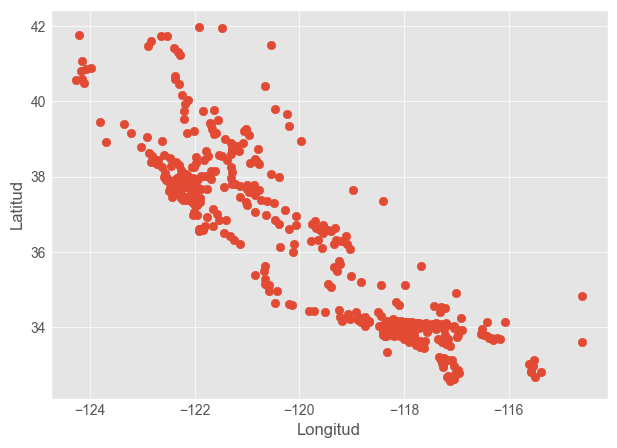

In [18]:
# Generemos una primera gráfica de dispersión con las variables
# longitud (eje horizontal) y latitud (eje vertical)
fig, ax = plt.subplots()

# Graficar y etiquetar los ejes
ax.scatter(longitud, latitud)
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud');

Lo interesante de este tipo de gráficas es que, además de las variables originales (longitud, latitud), podemos jugar por ejemplo con el tamaño de cada punto y hacer que éste dependa de una tercera variable.

Hagamos que el tamaño de cada punto sea proporcional al área en Km^2 de cada ciudad. Para esto usaremos el parámetro `s` al momento de generar la gráfica:

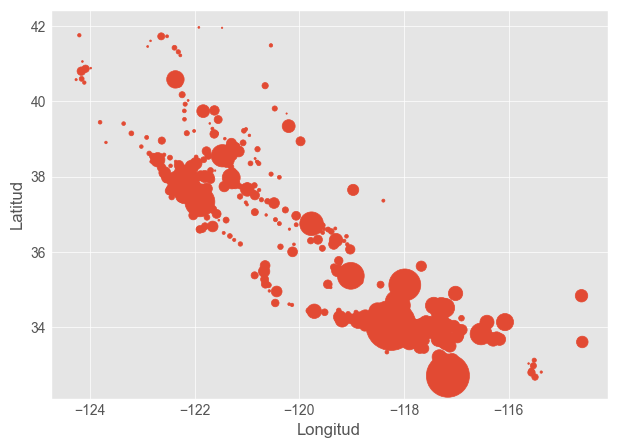

In [20]:
# Generemos una primera gráfica de dispersión con las variables
# longitud (eje horizontal) y latitud (eje vertical)
fig, ax = plt.subplots()

# Graficar incluyendo áreas y etiquetar los ejes
ax.scatter(longitud, latitud, s = area)
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud');

¡Mucho mejor!

Pero los círculos no resultan fáciles de diferenciar. Así que cambiemos el mapa de color usando el argumento `cmap`, pero hagamos además que los círculos tengan diferentes colores dependiendo de la población (cuarta variable):

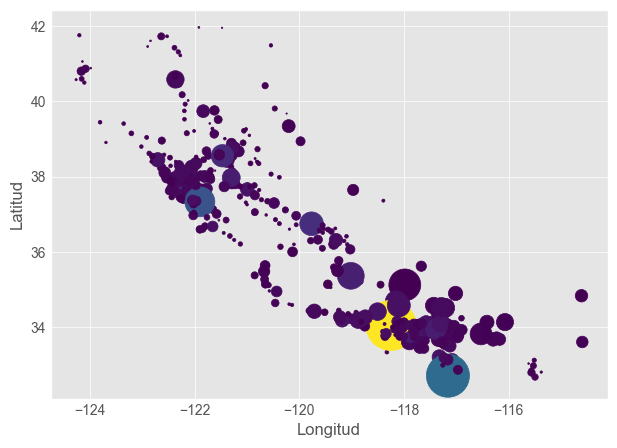

In [21]:
# Generemos una primera gráfica de dispersión con las variables
# longitud (eje horizontal) y latitud (eje vertical)
fig, ax = plt.subplots()

# Graficar incluyendo áreas, modificar mapa de color, añadir variable población y etiquetar los ejes
ax.scatter(longitud, latitud, s = area, 
           c = poblacion, cmap='viridis')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud');

Un poco mejor. Sin embargo, vemos muchos círculos de con colores similares (violeta) lo que nos indica que muchas ciudades tienen niveles de población muy cercanos.

Esto lo podemos verificar agregando una barra de color a la gráfica, usando la población como variable de interés:

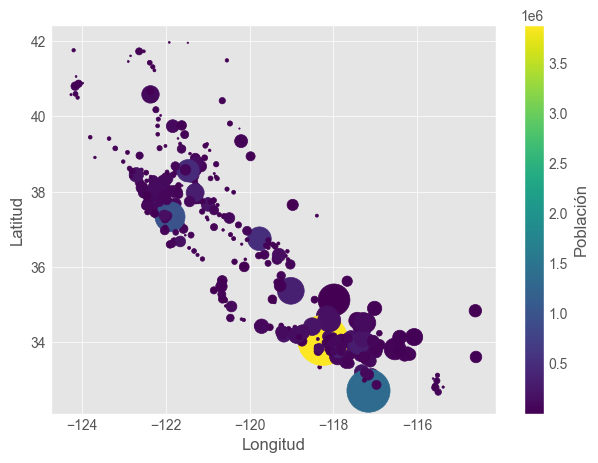

In [22]:
# Generemos una primera gráfica de dispersión con las variables
# longitud (eje horizontal) y latitud (eje vertical)
fig, ax = plt.subplots()

# Graficar incluyendo áreas, modificar mapa de color, añadir variable población,
# etiquetar los ejes y añadir barra de color
grafica = ax.scatter(longitud, latitud, s = area, 
           c = poblacion, cmap='viridis')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
fig.colorbar(grafica, label='Población');

Efectivamente, la escala de población es muy amplia y va desde casi 0 habitantes hasta casi los 4 millones.

Así que en este caso, en lugar de usar una escala líneal usaremos una escala logarítmica para "desenmascarar" los valores pequeños:

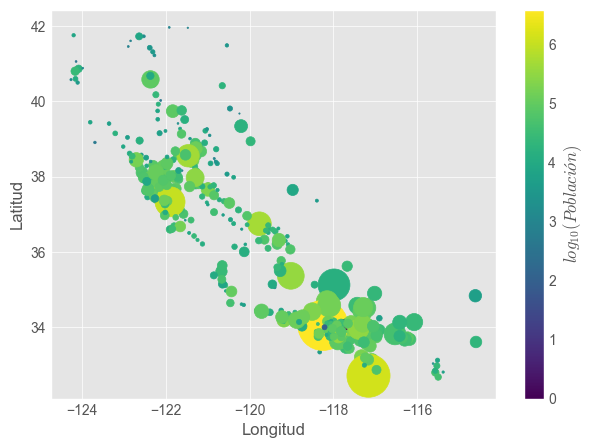

In [23]:
# Generemos una primera gráfica de dispersión con las variables
# longitud (eje horizontal) y latitud (eje vertical)
fig, ax = plt.subplots()

# Graficar incluyendo áreas, modificar mapa de color, añadir variable población
# escalada logarítmicamente, etiquetar los ejes y añadir barra de color
grafica = ax.scatter(longitud, latitud, s = area, 
           c = np.log10(poblacion), cmap='viridis')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
fig.colorbar(grafica, label='$log_{10}(Población)$');

Un poco mejor. Aunque ahora hay exceso de colores verdes.

Sin embargo, observemos que la mayoría de las ciudades está en el rango de población (escala logarítmica) de 2 a 7 aproximadamente.

Usemos estos límites mínimo y máximo al momento de generar la gráfica (fijando los parámetros `vmin` y `vmax`):

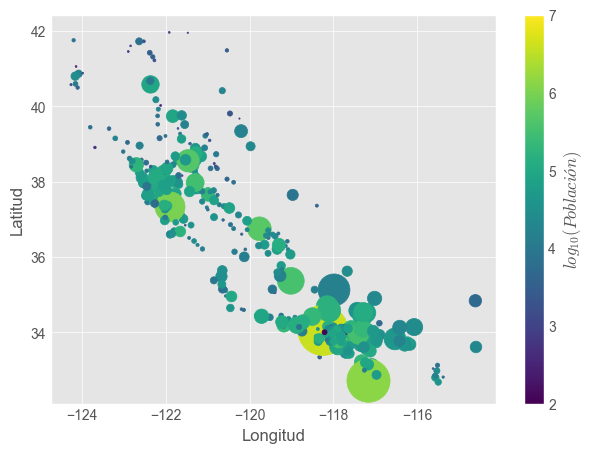

In [24]:
# Generemos una primera gráfica de dispersión con las variables
# longitud (eje horizontal) y latitud (eje vertical)
fig, ax = plt.subplots()

# Graficar incluyendo áreas, modificar mapa de color, añadir variable población
# escalada logarítmicamente, modificar valores mínimo y máximo, 
# etiquetar los ejes y añadir barra de color
grafica = ax.scatter(longitud, latitud, s = area, 
           c = np.log10(poblacion), cmap='viridis',
           vmin = 2, vmax = 7)
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
fig.colorbar(grafica, label='$log_{10}(Población)$');

Un poco mejor. Ahora agreguemos algo de transparencia a cada círculo para poderlos diferenciar aún mejor.

Esto lo podemos hacer con el parámetro `alpha`:

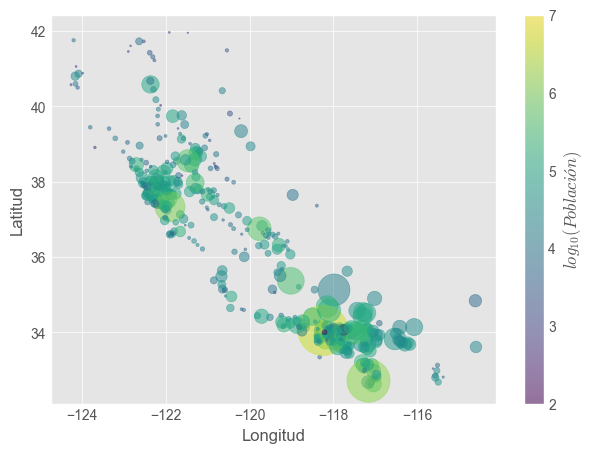

In [25]:
# Generemos una primera gráfica de dispersión con las variables
# longitud (eje horizontal) y latitud (eje vertical)
fig, ax = plt.subplots()

# Graficar incluyendo áreas, modificar mapa de color, añadir variable población
# escalada logarítmicamente, modificar valores mínimo y máximo, 
# agregar transparencia, etiquetar los ejes y añadir barra de color
grafica = ax.scatter(longitud, latitud, s = area, 
           c = np.log10(poblacion), cmap='viridis',
           vmin = 2, vmax = 7, alpha=0.5)
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
fig.colorbar(grafica, label='$log_{10}(Población)$');

¡Muchísimo mejor!

Para finalizar, sólo nos falta incluir la información del área en la gráfica, pues cada punto tiene un tamaño proporcional a esta área pero no hemos especificado los valores.

Añadiremos una leyenda en la esquina superior derecha, mostrando tres círculos correspondientes a áreas de 50, 250 y 500 Km^2. Además añadiremos el título a la gráfica:

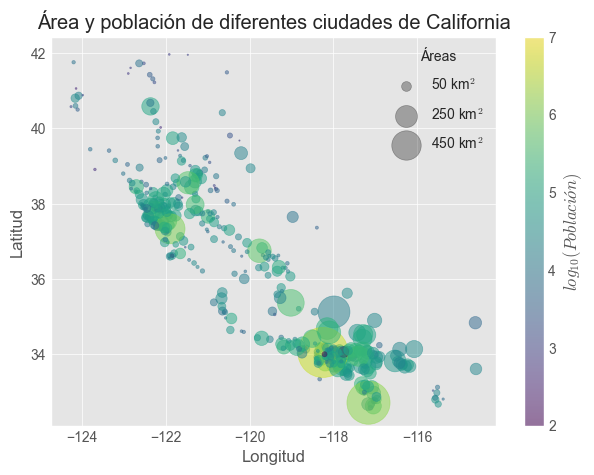

In [27]:
# Generemos una primera gráfica de dispersión con las variables
# longitud (eje horizontal) y latitud (eje vertical)
fig, ax = plt.subplots()

# Graficar incluyendo áreas, modificar mapa de color, añadir variable población
# escalada logarítmicamente, modificar valores mínimo y máximo, 
# agregar transparencia, etiquetar los ejes y añadir barra de color
grafica = ax.scatter(longitud, latitud, s = area, 
           c = np.log10(poblacion), cmap='viridis',
           vmin = 2, vmax = 7, alpha=0.5)
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
fig.colorbar(grafica, label='$log_{10}(Población)$')

# Leyenda
# - Añadir tres puntos de color gris (usando scatter) y con
#   tamaños proporcionales a 50, 250 y 450 Km^2
for areas in [50, 250, 450]:
    ax.scatter([], [], c='k', alpha=0.3, s=areas,
                label=str(areas) + ' km$^2$')
# - Y añadir legenda sin marco (frameon=False) y con un
#   espaciamiento adecuado entre el título y las etiquetas
#   (labelspacing=1)
ax.legend(labelspacing=1, title='Áreas');

# Título de la gráfica
ax.set_title('Área y población de diferentes ciudades de California');

Y podemos comparar el resultado que acabamos de obtener con la gráfica de dispersión generada inicialmente:

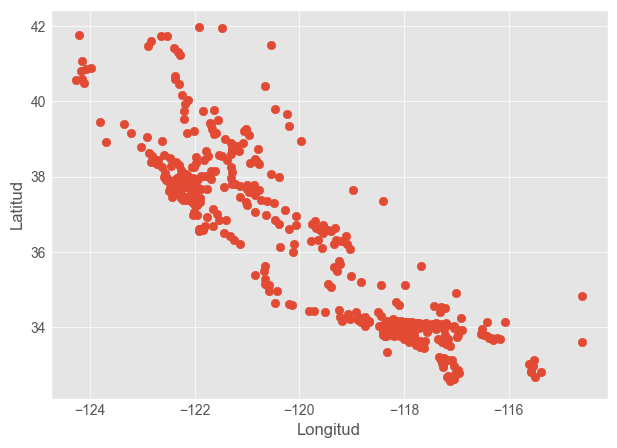

In [28]:
# Generemos una primera gráfica de dispersión con las variables
# longitud (eje horizontal) y latitud (eje vertical)
fig, ax = plt.subplots()

# Graficar y etiquetar los ejes
ax.scatter(longitud, latitud)
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud');

Definitivamente vemos lo versátil que es Matplotlib y cómo con un uso adecuado de las diferentes herramientas podemos generar visualizaciones muy llamativas.